In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

upload dataset

In [4]:
df = pd.read_csv("F:\\Project\\Student_Performance\\Data_Analysis\\data\\stud.csv")
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


EDA Process

check  data types of the dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


check null values of the dataset.

In [6]:
df.isnull().sum().sum()

np.int64(0)

check duplicates values of the dataset

In [7]:
df.duplicated().sum()

np.int64(0)

check value count of the dataset.

In [8]:
for i in df.columns:
    print(f"column is {i} and its datatype:{df[i].dtype}")
    print(df[i].value_counts())
    print(f"**"*15)



column is gender and its datatype:object
gender
female    518
male      482
Name: count, dtype: int64
******************************
column is race_ethnicity and its datatype:object
race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
******************************
column is parental_level_of_education and its datatype:object
parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
******************************
column is lunch and its datatype:object
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
******************************
column is test_preparation_course and its datatype:object
test_preparation_course
none         642
completed    358
Name: count, dtype: int64
******************************
column is math_score and its datatype:int64
math_sco

 check unique values in the dataset

In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

check statisticalsummay of daaset

In [10]:
df.describe(include='all')

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
count,1000,1000,1000,1000,1000,1000.00000,1000.000000,1000.000000
unique,2,5,6,2,2,NaN,NaN,NaN
top,female,group C,some college,standard,none,NaN,NaN,NaN
freq,518,319,226,645,642,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,66.08900,69.169000,68.054000
std,NaN,NaN,NaN,NaN,NaN,15.16308,14.600192,15.195657
min,NaN,NaN,NaN,NaN,NaN,0.00000,17.000000,10.000000
25%,NaN,NaN,NaN,NaN,NaN,57.00000,59.000000,57.750000
50%,NaN,NaN,NaN,NaN,NaN,66.00000,70.000000,69.000000
75%,NaN,NaN,NaN,NaN,NaN,77.00000,79.000000,79.000000


* math_score: min=o, max= 100, avg=66.09
* reading_score: min =17, max=100, avg=69.16
* writing_score: min=10, max=100, avg=68.05

Identify numeric and object column

In [11]:
numeric_col=[feature for feature in df.columns if df[feature].dtype!='object']
categorical_col=[feature for feature in df.columns if df[feature].dtype =='object']

In [12]:
print(f"{numeric_col} \n")
print(f"{categorical_col} \n")

['math_score', 'reading_score', 'writing_score'] 

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course'] 



Count students who scored maximum marks in each subject

In [13]:
reading_full = df[df['reading_score']==100]["lunch"].count()
math_full = df[df['math_score']==100]["lunch"].count()
writing_full = df[df['writing_score']==100]["lunch"].count()


In [14]:
print(reading_full)
print(math_full)
print(writing_full)

17
7
14


count students who scored less than and equal to 20 in each subject.

In [15]:
reading = df[df['reading_score']<=20]["lunch"].count()
maths = df[df['math_score']<=20]["lunch"].count()
writing = df[df['writing_score']<=20]["lunch"].count()


In [16]:
print(reading)
print(maths)
print(writing)

1
4
3


Add new column(avg_score and total) in dataset.

In [17]:
df["avg_score"] = (df["math_score"] +df["reading_score"]+ df["writing_score"])/3
df["Total"] = df["math_score"] +df["reading_score"]+ df["writing_score"]

df.head(3)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,avg_score,Total
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,218
1,female,group C,some college,standard,completed,69,90,88,82.333333,247
2,female,group B,master's degree,standard,none,90,95,93,92.666667,278


 # Visulaization
* visualization of Distribution of average score.
* visualization of Distribution of average score by gender

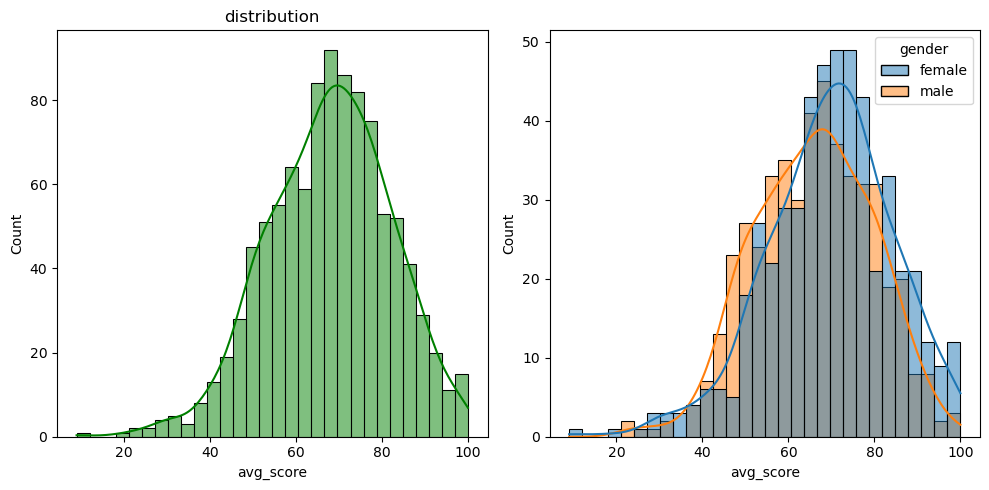

In [18]:
plt.subplots(1,2,figsize = (10,5))

plt.subplot(1,2,1)
sns.histplot(data=df,x="avg_score",kde=True,bins=30,color="green")
plt.title("distribution")

plt.subplot(1,2,2)
sns.histplot(data=df,x="avg_score",kde=True,bins=30,color="green",hue='gender')
plt.tight_layout()
plt.show()



* Most students have an average score between 60 and 80.
* Very few students have extremely low or extremely high score.
* Female students show a slightly higher average score than male students.


visualization of average score distribution by lunch.

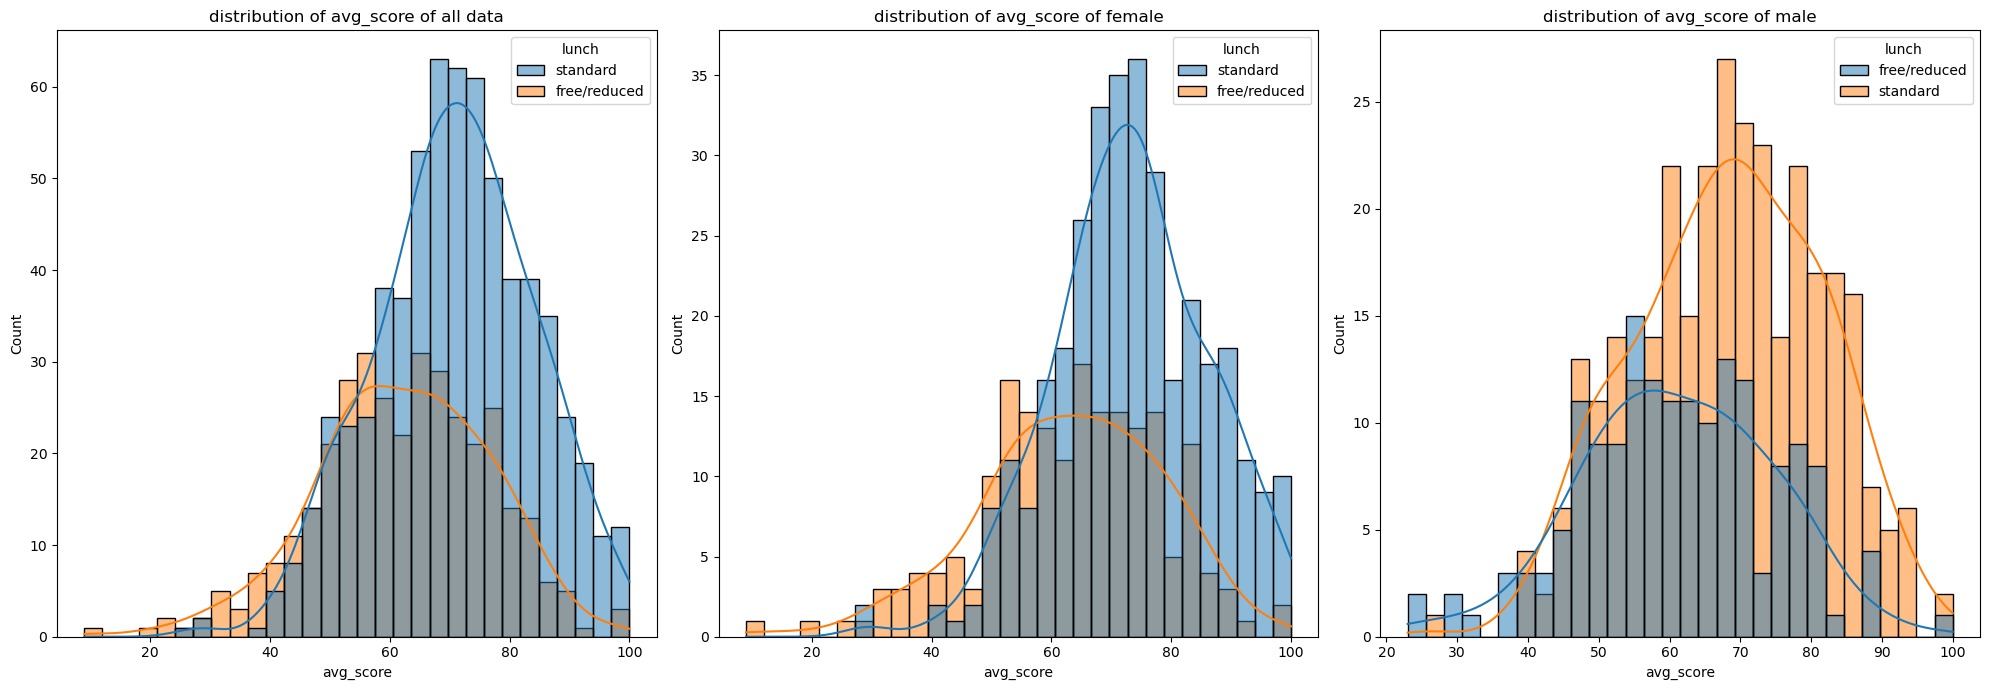

In [19]:
plt.subplots(1,3,figsize=(20,7))

plt.subplot(1,3,1)
sns.histplot(data=df,x="avg_score",kde=True,bins=30,color="green",hue="lunch")
plt.title("distribution of avg_score of all data")

plt.subplot(1,3,2)
sns.histplot(data=df[df['gender']=='female'],x="avg_score",kde=True,bins=30,color="green",hue="lunch")
plt.title("distribution of avg_score of female")

plt.subplot(1,3,3)
sns.histplot(data=df[df['gender']=='male'],x="avg_score",kde=True,bins=30,color="green",hue="lunch")
plt.title("distribution of avg_score of male")
plt.tight_layout()
plt.show()


* Stuendts who receive standard lunch are higher in number and have a higher average score.

Visualization of avg_score  distribution by parental level of education.

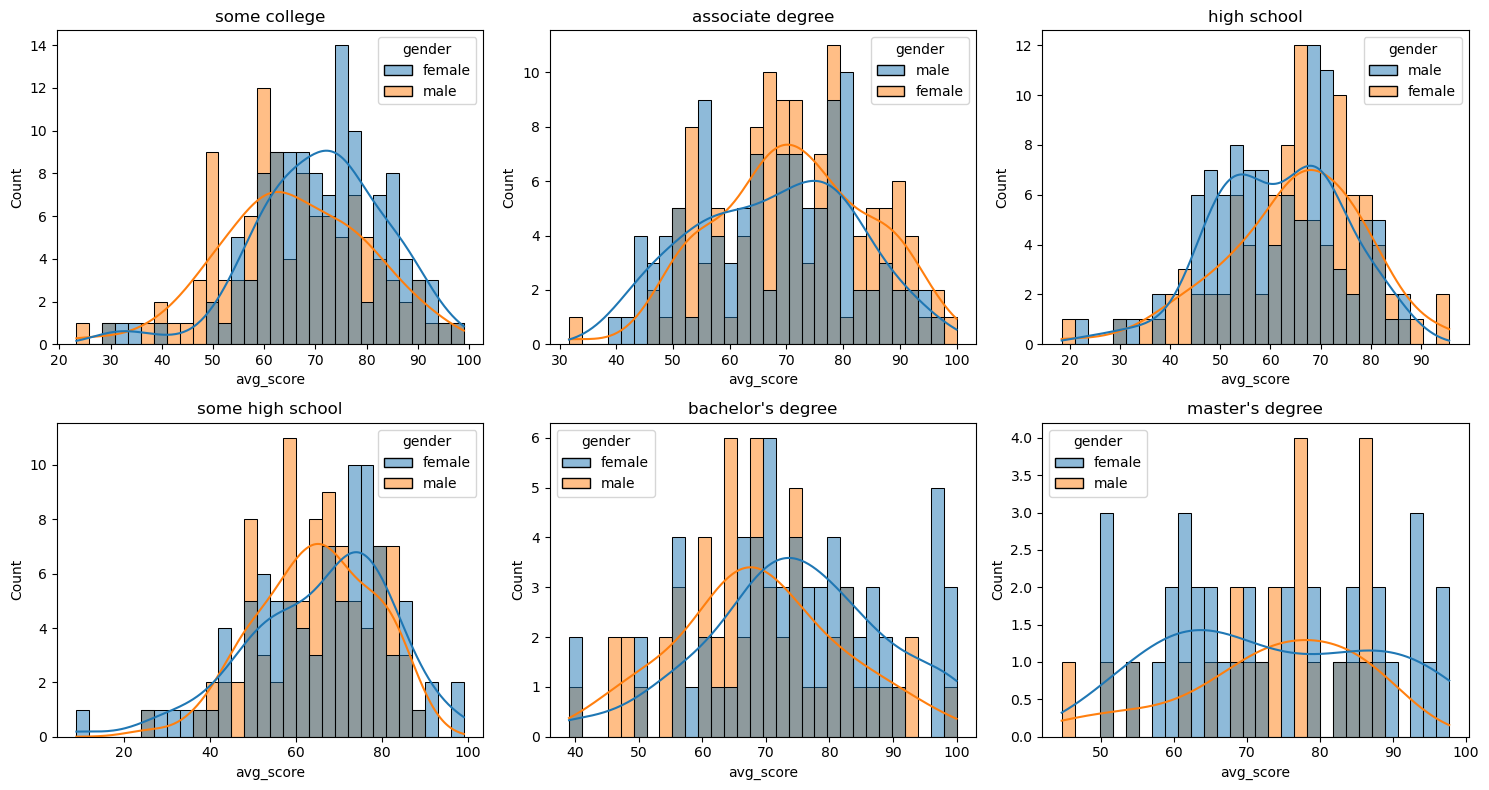

In [20]:
plt.subplots(2,3,figsize=(15,8))

plt.subplot(2,3,1)
sns.histplot(data=df[df["parental_level_of_education"]=="some college"],x="avg_score",kde=True,bins=30,hue='gender')
plt.title("some college")


plt.subplot(2,3,2)
sns.histplot(data=df[df["parental_level_of_education"]=="associate's degree"],x="avg_score",kde=True,bins=30,hue="gender")
plt.title("associate degree")

plt.subplot(2,3,3)
sns.histplot(data=df[df["parental_level_of_education"]=="high school"],x="avg_score",kde=True,bins=30,hue="gender")
plt.title("high school")

plt.subplot(2,3,4)
sns.histplot(data=df[df["parental_level_of_education"]=="some high school"],x="avg_score",kde=True,bins=30,hue="gender")
plt.title("some high school")

plt.subplot(2,3,5)
sns.histplot(data=df[df["parental_level_of_education"]=="bachelor's degree"],x="avg_score",kde=True,bins=30,hue="gender")
plt.title("bachelor's degree")

plt.subplot(2,3,6)
sns.histplot(data=df[df["parental_level_of_education"]=="master's degree"],x="avg_score",kde=True,bins=30,hue="gender")
plt.title("master's degree")
plt.tight_layout()
plt.show()

* Female students generally have higher average score than male students across four parental education level.
* for the master's degree, male and female students have nearly similar average scores.

check value_count of race/ethnicity column.

In [21]:
df['race_ethnicity'].value_counts()

race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

Visualization  of avg_score  distribution by race/ethnicity.

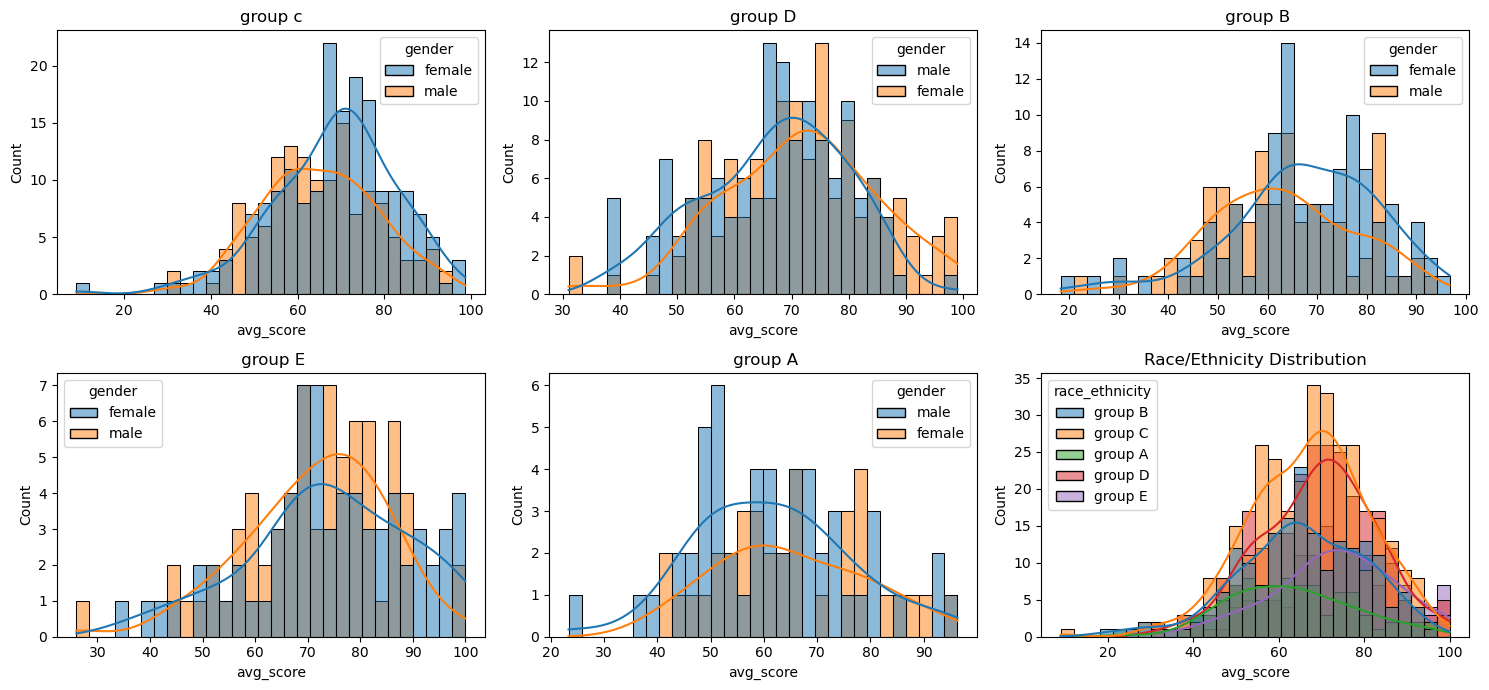

In [22]:
plt.subplots(2,3,figsize=(15,7))

plt.subplot(2,3,1)
sns.histplot(data=df[df['race_ethnicity']=='group C'], x='avg_score',kde=True,bins=30,hue='gender')
plt.title("group c")

plt.subplot(2,3,2)
sns.histplot(data=df[df['race_ethnicity']=='group D'],x="avg_score",kde=True,bins=30,hue="gender")
plt.title("group D")


plt.subplot(2,3,3)
sns.histplot(data=df[df['race_ethnicity']=='group B'],x="avg_score",kde=True,bins=30,hue='gender')
plt.title(" group B")


plt.subplot(2,3,4)
sns.histplot(data=df[df['race_ethnicity']=='group E'],x="avg_score",kde=True,bins=30,hue="gender")
plt.title(" group E")

plt.subplot(2,3,5)
sns.histplot(data=df[df['race_ethnicity']=='group A'],x="avg_score",kde=True,bins=30,hue="gender")
plt.title(" group A")

plt.subplot(2,3,6)
sns.histplot(data=df,x="avg_score",kde=True,bins=30,hue="race_ethnicity")
plt.title("Race/Ethnicity Distribution")


plt.tight_layout()
plt.show()


* In group C female perform better than male.
* In group E and group D male perform better than female.
* In group A and group C both male and female perform average.
* Group C perform bettan than others groups.


* Visualization of maths and avg_score by gender wise.

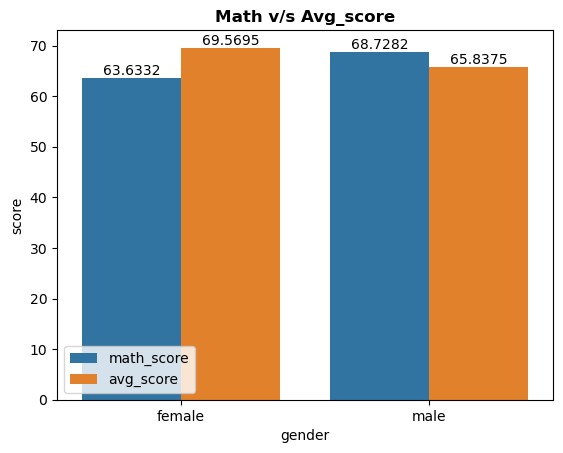

In [23]:
plot_data= df.groupby('gender')[['math_score','avg_score']].mean().reset_index()

plot_data=plot_data.melt(id_vars='gender',var_name='score_type',value_name='score')

ax = sns.barplot(data=plot_data,x='gender',y='score',hue='score_type')
for container in ax.containers:
    ax.bar_label(container)
plt.legend()
plt.title("Math v/s Avg_score",c='black',fontweight='bold')
plt.show()

* Female Students scored lower in maths but perform better in the average score.
* Male students scored higher in maths but had a lower average score. 

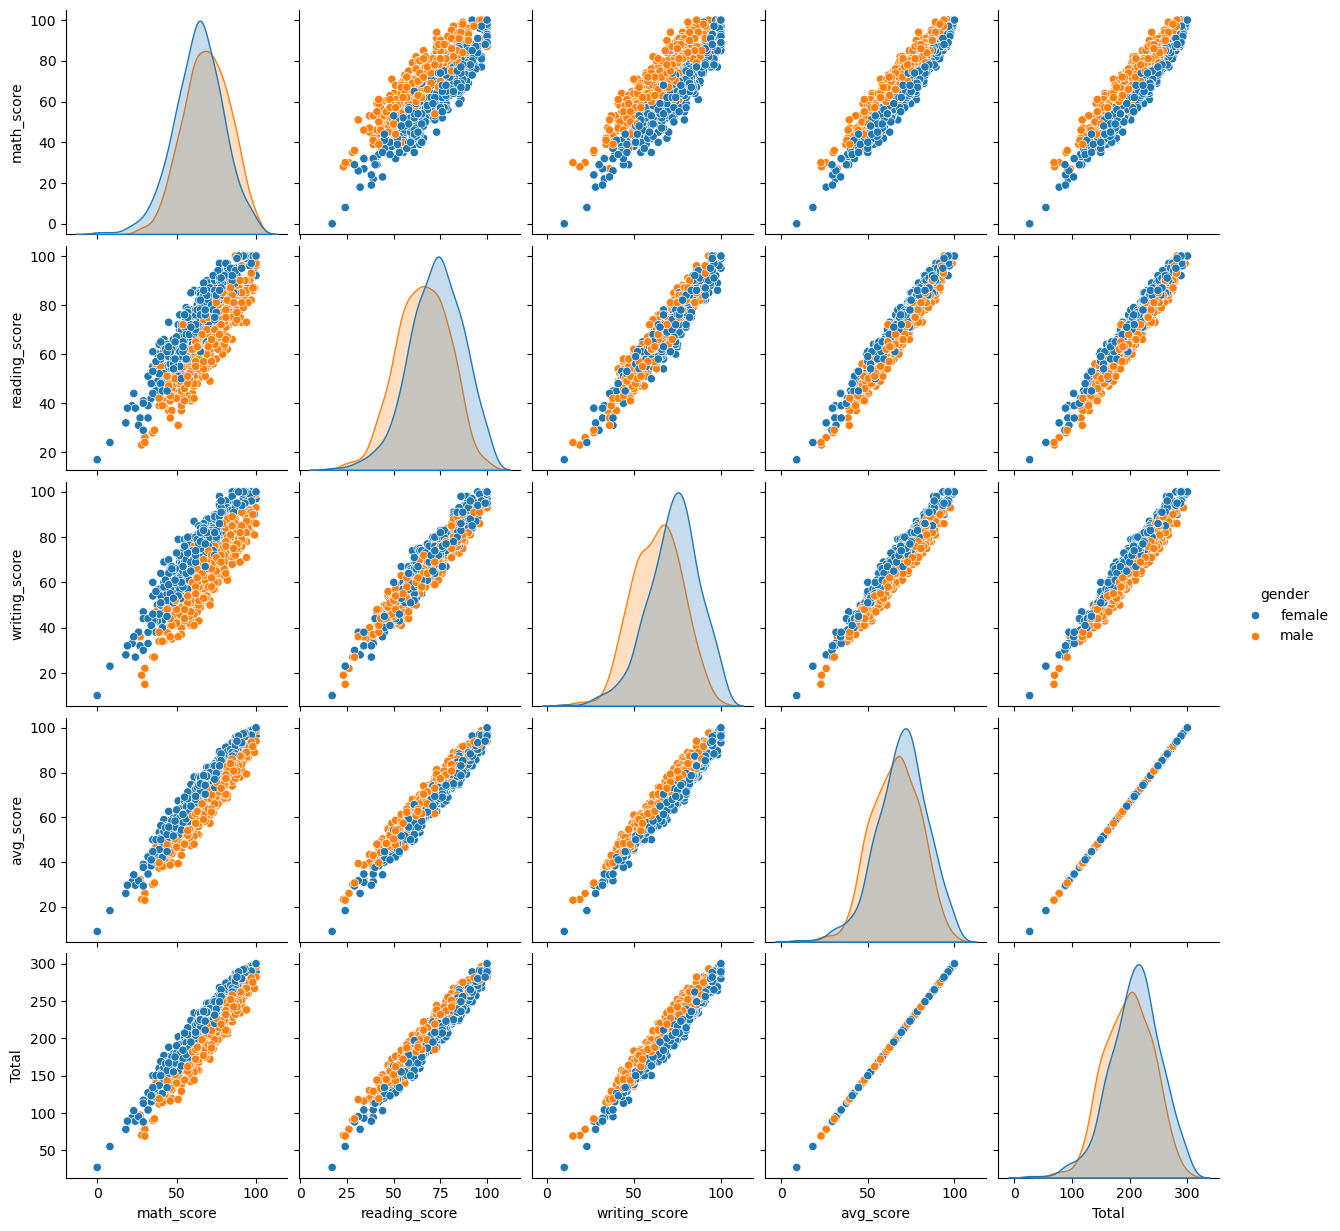

In [24]:
sns.pairplot(df,hue='gender')
plt.show()

* Average score and total score have a very strong positive relationship.
* Math,readind and writing score have a strong realtionship.
* Female students generally perform better in reading and wrting , while male students perform slightly better in mathss

* # Check outlier

In [38]:
for i in df.columns:
    if df[i].dtype != "object":
        q1 = df[i].quantile(0.25)
        q3= df[i].quantile(0.75)
        IQR = q3-q1
        lower=q1-1.5*IQR
        upper =q3+1.5*IQR

        outlier = df[(df[i]<lower)|(df[i]>upper)]
        print(i,":",len(outlier))

        

math_score : 8
reading_score : 6
writing_score : 5
avg_score : 6
Total : 6


* Visulization of outlier

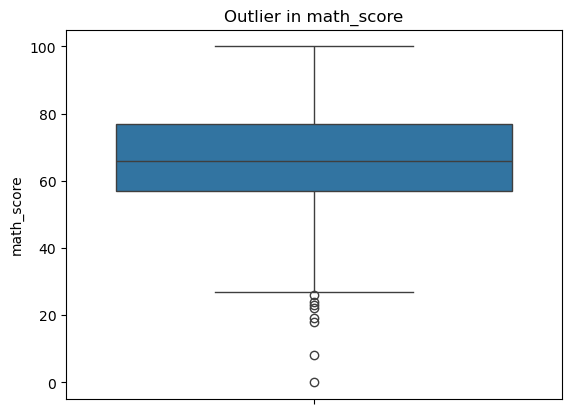

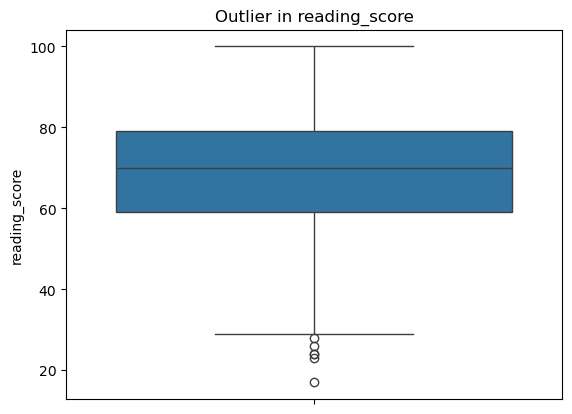

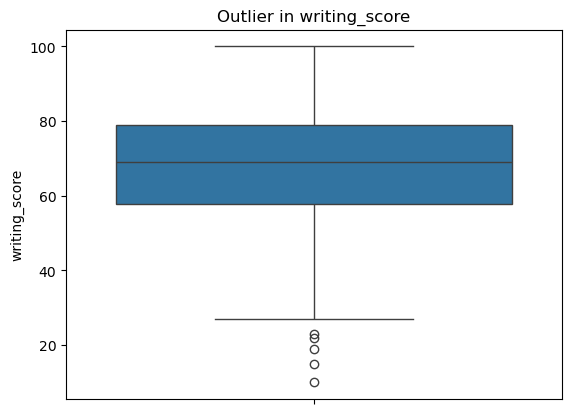

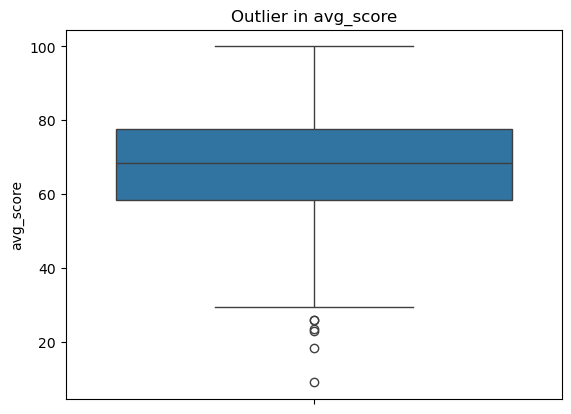

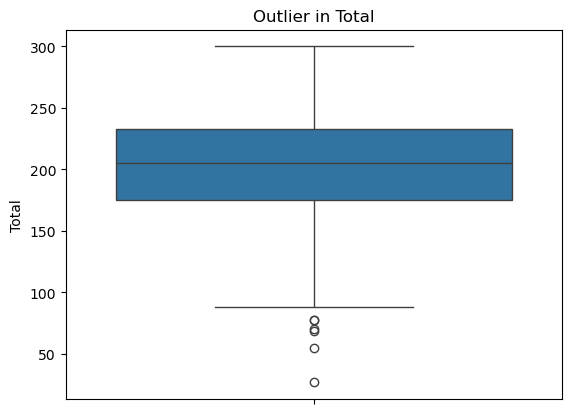

In [37]:
for i in df.columns:
    if df[i].dtype != "object":
        sns.boxplot(data=df[i])
        plt.title(f'Outlier in {i}')
        plt.show()

* Outlier are present in all numerical columns and all of them are below the lower bound.
* Since this is the student dataset , the outlier may represent genuine observation, so the outlier are not removed.


# Visualization in maths_score